# 1.. Getting High level overview of Data !

In [79]:
# --- This cell performs part of the TMDB recommendation pipeline ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [80]:
# --- This cell performs part of the TMDB recommendation pipeline ---
'''

The first dataset "credits.csv" contains the following features:-

movie_id - A unique identifier for each movie.
cast - The name of lead and supporting actors.
crew - The name of Director, Editor, Composer, Writer etc.



The second dataset "movies.csv" has the following features:-

budget - The budget in which the movie was made.
genre - The genre of the movie, Action, Comedy ,Thriller etc.
homepage - A link to the homepage of the movie.
id - This is infact the movie_id as in the first dataset.
keywords - The keywords or tags related to the movie.
original_language - The language in which the movie was made.
original_title - The title of the movie before translation or adaptation.
overview - A brief description of the movie.
popularity - A numeric quantity specifying the movie popularity.
production_companies - The production house of the movie.
production_countries - The country in which it was produced.
release_date - The date on which it was released.
revenue - The worldwide revenue generated by the movie.
runtime - The running time of the movie in minutes.
status - "Released" or "Rumored".
tagline - Movie's tagline.
title - Title of the movie.
vote_average - average ratings the movie recieved.
vote_count - the count of votes recieved.

'''

'\n\nThe first dataset "credits.csv" contains the following features:-\n\nmovie_id - A unique identifier for each movie.\ncast - The name of lead and supporting actors.\ncrew - The name of Director, Editor, Composer, Writer etc.\n\n\n\nThe second dataset "movies.csv" has the following features:-\n\nbudget - The budget in which the movie was made.\ngenre - The genre of the movie, Action, Comedy ,Thriller etc.\nhomepage - A link to the homepage of the movie.\nid - This is infact the movie_id as in the first dataset.\nkeywords - The keywords or tags related to the movie.\noriginal_language - The language in which the movie was made.\noriginal_title - The title of the movie before translation or adaptation.\noverview - A brief description of the movie.\npopularity - A numeric quantity specifying the movie popularity.\nproduction_companies - The production house of the movie.\nproduction_countries - The country in which it was produced.\nrelease_date - The date on which it was released.\nre

In [81]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits = pd.read_csv(r"../dataset/tmdb_5000_credits.csv")

In [82]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies = pd.read_csv(r"../dataset/tmdb_5000_movies.csv")

In [83]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits.head(n = 7)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
5,559,Spider-Man 3,"[{""cast_id"": 30, ""character"": ""Peter Parker / ...","[{""credit_id"": ""52fe4252c3a36847f80151a5"", ""de..."
6,38757,Tangled,"[{""cast_id"": 34, ""character"": ""Flynn Rider (vo...","[{""credit_id"": ""52fe46db9251416c91062101"", ""de..."


# 2.. Doing data Preparation !

In [84]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies.head(5)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [85]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='object')

In [86]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits.columns

Index(['movie_id', 'title', 'cast', 'crew'], dtype='object')

In [87]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits_updated_df = credits.rename(columns = {"movie_id" : "id"})

In [88]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits_updated_df

,id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...
4798,9367,El Mariachi,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,72766,Newlyweds,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,231617,"Signed, Sealed, Delivered","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,126186,Shanghai Calling,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [89]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies.shape

(4803, 20)

In [90]:
# --- This cell performs part of the TMDB recommendation pipeline ---
credits_updated_df.shape

(4803, 4)

In [91]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_df_merge = movies.merge(credits_updated_df , on = "id")

In [92]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_df_merge.shape

(4803, 23)

In [93]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_df_merge.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'title_y', 'cast', 'crew'],
      dtype='object')

In [94]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_cleaned_df = movies_df_merge.drop(columns = ['homepage' , 'title_x' , 'title_y' ,'status' , 'production_countries'])

In [95]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_cleaned_df.shape

(4803, 18)

In [96]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_cleaned_df.head(2)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


# 3.. Understanding Average weighted Recommendation System !

In [97]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_cleaned_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew'],
      dtype='object')

![image.png](attachment:image.png)


                  Source: http://trailerpark.weebly.com/imdb-rating.html?source=post_page---------------------------

In [98]:
# --- This cell performs part of the TMDB recommendation pipeline ---
v = movies_cleaned_df['vote_count']
R = movies_cleaned_df['vote_average']
C = movies_cleaned_df['vote_average'].mean()

In [99]:
# --- This cell performs part of the TMDB recommendation pipeline ---
C

## mean rating for all the movies is approx 6.09 on a scale of 10

np.float64(6.092171559442016)

In [100]:
#### The next step is to determine an appropriate value for m ( minimum votes required to be listed in the chart)..

In [101]:
# --- This cell performs part of the TMDB recommendation pipeline ---
movies_cleaned_df[['original_title' , 'vote_count']]

,original_title,vote_count
0,Avatar,11800
1,Pirates of the Caribbean: At World's End,4500
2,Spectre,4466
3,The Dark Knight Rises,9106
4,John Carter,2124
...,...,...
4798,El Mariachi,238
4799,Newlyweds,5
4800,"Signed, Sealed, Delivered",6
4801,Shanghai Calling,7


<Axes: xlabel='vote_count'>

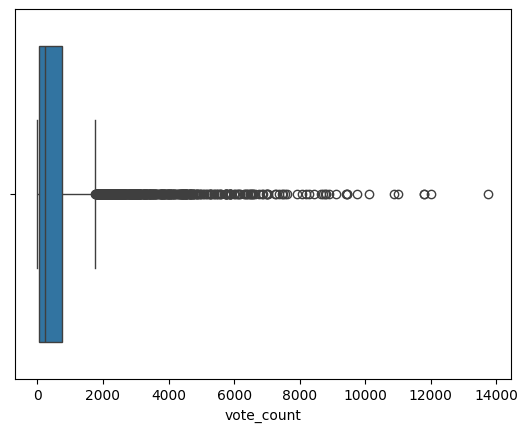

In [102]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sns.boxplot(data= movies_cleaned_df , x = 'vote_count')

In [103]:
## m = 1900

In [104]:
# --- This cell performs part of the TMDB recommendation pipeline ---
'''

We will use 90th percentile as our cutoff. 
In other words, for a movie to feature in the charts, 
It must have more votes than at least 90% of the movies in the list.

'''

'\n\nWe will use 90th percentile as our cutoff. \nIn other words, for a movie to feature in the charts, \nIt must have more votes than at least 90% of the movies in the list.\n\n'

# 4.. Building Average Weighted Recommendation System !

In [105]:
# --- This cell performs part of the TMDB recommendation pipeline ---
threshold = movies_cleaned_df['vote_count'].quantile(q = 0.9)

In [106]:
## movies_cleaned_df['vote_count'].quantile(q = 0.92)

In [107]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df = movies_cleaned_df[movies_cleaned_df['vote_count']>=threshold]

In [108]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4291,1200000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 9648, ""n...",176,"[{""id"": 1366, ""name"": ""shotgun""}, {""id"": 13000...",en,Saw,Obsessed with teaching his victims the value o...,63.655973,"[{""name"": ""Lions Gate Films"", ""id"": 35}, {""nam...",2004-10-01,103911669,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Live or die. Make your choice.,7.2,2184,"[{""cast_id"": 4, ""character"": ""Dr. Lawrence Gor...","[{""credit_id"": ""52fe4223c3a36847f8006c57"", ""de..."
4300,1200000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 53, ""name...",500,"[{""id"": 2052, ""name"": ""traitor""}, {""id"": 6099,...",en,Reservoir Dogs,A botched robbery indicates a police informant...,66.925866,"[{""name"": ""Live Entertainment"", ""id"": 285}, {""...",1992-09-02,14661007,99.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Every dog has his day.,8.0,3697,"[{""cast_id"": 20, ""character"": ""Mr. White/Larry...","[{""credit_id"": ""52fe424ac3a36847f8012cb9"", ""de..."
4302,1200000,"[{""id"": 37, ""name"": ""Western""}]",429,"[{""id"": 801, ""name"": ""bounty hunter""}, {""id"": ...",it,"Il buono, il brutto, il cattivo",Whi

In [109]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.shape

(481, 18)

In [110]:
## R,v,C,m

In [111]:
# --- This cell performs part of the TMDB recommendation pipeline ---
m = threshold

In [112]:
# --- This cell performs part of the TMDB recommendation pipeline ---
m

np.float64(1838.4000000000015)

In [113]:
# --- This cell performs part of the TMDB recommendation pipeline ---
R

0       7.2
1       6.9
2       6.3
3       7.6
4       6.1
       ... 
4798    6.6
4799    5.9
4800    7.0
4801    5.7
4802    6.3
Name: vote_average, Length: 4803, dtype: float64

In [114]:
# --- This cell performs part of the TMDB recommendation pipeline ---
v

0       11800
1        4500
2        4466
3        9106
4        2124
        ...  
4798      238
4799        5
4800        6
4801        7
4802       16
Name: vote_count, Length: 4803, dtype: int64

In [115]:
# --- This cell performs part of the TMDB recommendation pipeline ---
C

np.float64(6.092171559442016)

In [116]:
# --- This cell performs part of the TMDB recommendation pipeline ---
v = filtered_df['vote_count']
R = filtered_df['vote_average']
C = filtered_df['vote_average'].mean()

In [117]:
# --- This cell performs part of the TMDB recommendation pipeline ---
v

0       11800
1        4500
2        4466
3        9106
4        2124
        ...  
4291     2184
4300     3697
4302     2311
4337     2535
4602     2078
Name: vote_count, Length: 481, dtype: int64

In [118]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df['weighted_avg'] = ((R*v) + (C*m))/(v+m)

In [119]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.492998
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.500396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4291,1200000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 9648, ""n...",176,"[{""id"": 1366, ""name"": ""shotgun""}, {""id"": 13000...",en,Saw,Obsessed with teaching his victims the value o...,63.655973,"[{""name"": ""Lions Gate Films"", ""id"": 35}, {""nam...",2004-10-01,103911669,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Live or die. Make your choice.,7.2,2184,"[{""cast_id"": 4, ""character"": ""Dr. Lawrence Gor...","[{""credit_id"": ""52fe4223c3a36847f8006c57"", ""de...",7.091679
4300,1200000,"[{""id"": 80, ""name"": ""Crime""}, {""id"": 53, ""name...",500,"[{""id"": 2052, ""name"": ""traitor""}, {""id"": 6099,...",en,Reservoir Dogs,A botched robbery indicates a police informant...,66.925866,"[{""name"": ""Live Entertainment"", ""id"": 285}, {""...",1992-09-02,14661007,99.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Every dog has his day.,8.0,3697,"[{""cast_id"": 20, ""character"": ""Mr. White/Larry...","[{""credit_id"": ""52fe424ac3a36847f8012cb9"", ""de...",7.655593
4302,1200000,"[{""id"": 37, ""name"": ""Western""}]",429,"[{""id"": 801, ""na

In [120]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [121]:
# --- This cell performs part of the TMDB recommendation pipeline ---
df_sorted_ranking = filtered_df.sort_values('weighted_avg' , ascending= False).head(20)

In [122]:
# --- This cell performs part of the TMDB recommendation pipeline ---
df_sorted_ranking.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [123]:
# --- This cell performs part of the TMDB recommendation pipeline ---
df_sorted_ranking[['original_title' , 'vote_average', 'vote_count' , 'weighted_avg' , 'popularity']]

,original_title,vote_average,vote_count,weighted_avg,popularity
1881,The Shawshank Redemption,8.5,8205,8.218658,136.747729
662,Fight Club,8.3,9413,8.081543,146.757391
3232,Pulp Fiction,8.3,8428,8.060583,121.463076
3337,The Godfather,8.4,5893,8.058304,143.659698
65,The Dark Knight,8.2,12002,8.035690,187.322927
809,Forrest Gump,8.2,7927,7.967126,138.133331
96,Inception,8.1,13752,7.965926,167.583710
95,Interstellar,8.1,10867,7.935482,724.247784
1990,The Empire Strikes Back,8.2,5879,7.905327,78.517830
1818,Schindler's List,8.3,4329,7.901461,104.469351


In [124]:
# --- This cell performs part of the TMDB recommendation pipeline ---
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

<Axes: xlabel='weighted_avg', ylabel='original_title'>

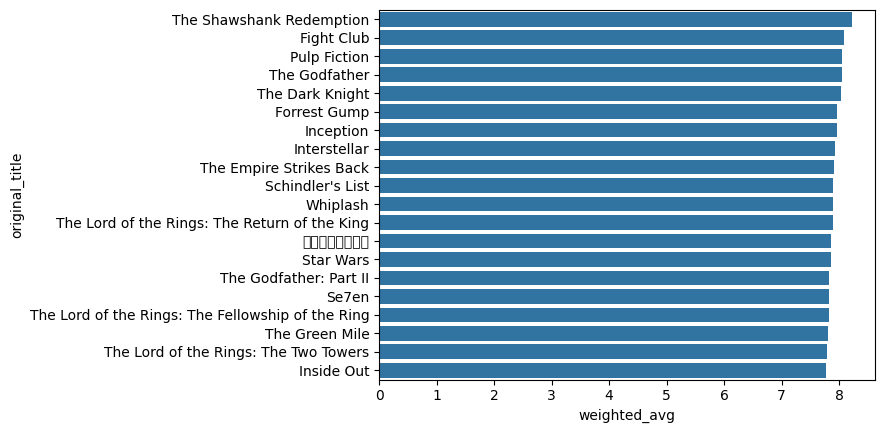

In [125]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sns.barplot(x = df_sorted_ranking['weighted_avg'] , y = df_sorted_ranking['original_title'])

# 5.. Building Popularity based Recommender System !

In [126]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [127]:
# --- This cell performs part of the TMDB recommendation pipeline ---
popularity_df = filtered_df.sort_values('popularity' , ascending= False)

In [128]:
# --- This cell performs part of the TMDB recommendation pipeline ---
popularity_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
546,74000000,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 16, ""...",211672,"[{""id"": 3487, ""name"": ""assistant""}, {""id"": 179...",en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",875.581305,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",2015-06-17,1156730962,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Before Gru, they had a history of bad bosses",6.4,4571,"[{""cast_id"": 22, ""character"": ""Scarlet Overkil...","[{""credit_id"": ""5431b2b10e0a2656e20026c7"", ""de...",6.561483
95,165000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",157336,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Interstellar,Interstellar chronicles the adventures of a gr...,724.247784,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2014-11-05,675120017,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Mankind was born on Earth. It was never meant ...,8.1,10867,"[{""cast_id"": 9, ""character"": ""Joseph Cooper"", ...","[{""credit_id"": ""52fe4bbf9251416c910e4801"", ""de...",7.935482
788,58000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",293660,"[{""id"": 2095, ""name"": ""anti hero""}, {""id"": 307...",en,Deadpool,Deadpool tells the origin story of former Spec...,514.569956,"[{""name"": ""Twentieth Century Fox Film Corporat...",2016-02-09,783112979,108.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Witness the beginning of a happy ending,7.4,10995,"[{""cast_id"": 99, ""character"": ""Wade Wilson / D...","[{""credit_id"": ""56c986b2925141172f0068b6"", ""de...",7.337398
94,170000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",118340,"[{""id"": 8828, ""name"": ""marvel comic""}, {""id"": ...",en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",481.098624,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...",2014-07-30,773328629,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",All heroes start somewhere.,7.9,9742,"[{""cast_id"": 1, ""character"": ""Peter Quill / St...","[{""credit_id"": ""538ce329c3a3687155003358"", ""de...",7.751249
127,150000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",76341,"[{""id"": 2964, ""name"": ""future""}, {""id"": 3713, ...",en,Mad Max: Fury Road,An apocalyptic story set in the furthest reach...,434.278564,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",2015-05-13,378858340,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",What a Lovely Day.,7.2,9427,"[{""cast_id"": 2, ""character"": ""Max Rockatansky""...","[{""credit_id"": ""577da370c3a36817f8003838"", ""de...",7.161323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,160000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",49538,"[{""id"": 591, ""name"": ""cia""}, {""id"": 1852, ""nam...",en,X-Men: First Class,Before Charles Xavier and Erik Lensherr took t...,3.195174,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2011-05-24,353624124,132.0,"[{""iso_639_1"": ""de"", ""name"": ""Deutsch""}, {""iso...",Witness the moment that will change our world.,7.1,5181,"[{""cast_id"": 22, ""character"": ""Charles Xavier ...","[{""credit_id"": ""538d861cc3a368714300461d"", ""de...",7.064118
203,110000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",36658,"[{""id"": 1852, ""name"": ""mutant""}, {""id"": 8828, ...",en,X2,Professor Charles Xavier and his team of genet...,2.871739,"[{""name"": ""Twentieth Century Fox Film Corporat...",2003-04-24,407711549,133.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",The time has come for those who are different ...,6.8,3506,"[{""cast_id"": 8, ""character"": ""Charles Xavier /...","[{""credit_id"": ""538c6cb00e0a26671200400a"", ""de...",6.856068
508,73000

<Axes: ylabel='original_title'>

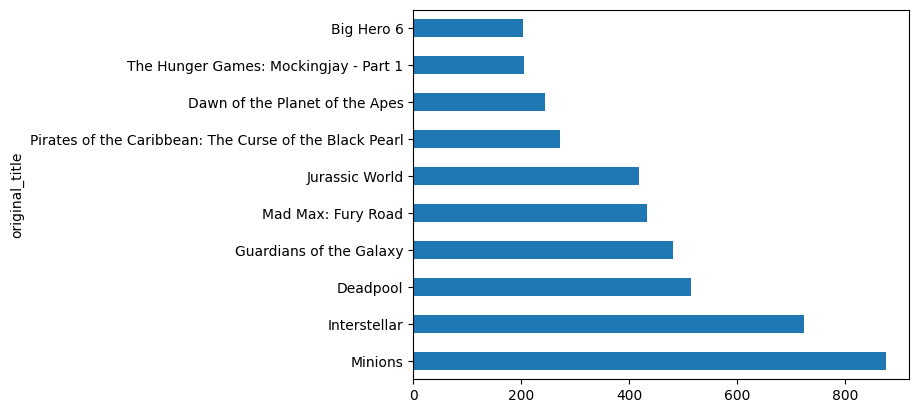

In [129]:
# --- This cell performs part of the TMDB recommendation pipeline ---
popularity_df.set_index('original_title')['popularity'][0:10].plot.barh()

In [130]:
# --- This cell performs part of the TMDB recommendation pipeline ---
popularity_df

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,revenue,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg
546,74000000,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 16, ""...",211672,"[{""id"": 3487, ""name"": ""assistant""}, {""id"": 179...",en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",875.581305,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",2015-06-17,1156730962,91.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Before Gru, they had a history of bad bosses",6.4,4571,"[{""cast_id"": 22, ""character"": ""Scarlet Overkil...","[{""credit_id"": ""5431b2b10e0a2656e20026c7"", ""de...",6.561483
95,165000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",157336,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Interstellar,Interstellar chronicles the adventures of a gr...,724.247784,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2014-11-05,675120017,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Mankind was born on Earth. It was never meant ...,8.1,10867,"[{""cast_id"": 9, ""character"": ""Joseph Cooper"", ...","[{""credit_id"": ""52fe4bbf9251416c910e4801"", ""de...",7.935482
788,58000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",293660,"[{""id"": 2095, ""name"": ""anti hero""}, {""id"": 307...",en,Deadpool,Deadpool tells the origin story of former Spec...,514.569956,"[{""name"": ""Twentieth Century Fox Film Corporat...",2016-02-09,783112979,108.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Witness the beginning of a happy ending,7.4,10995,"[{""cast_id"": 99, ""character"": ""Wade Wilson / D...","[{""credit_id"": ""56c986b2925141172f0068b6"", ""de...",7.337398
94,170000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",118340,"[{""id"": 8828, ""name"": ""marvel comic""}, {""id"": ...",en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",481.098624,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...",2014-07-30,773328629,121.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",All heroes start somewhere.,7.9,9742,"[{""cast_id"": 1, ""character"": ""Peter Quill / St...","[{""credit_id"": ""538ce329c3a3687155003358"", ""de...",7.751249
127,150000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",76341,"[{""id"": 2964, ""name"": ""future""}, {""id"": 3713, ...",en,Mad Max: Fury Road,An apocalyptic story set in the furthest reach...,434.278564,"[{""name"": ""Village Roadshow Pictures"", ""id"": 7...",2015-05-13,378858340,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",What a Lovely Day.,7.2,9427,"[{""cast_id"": 2, ""character"": ""Max Rockatansky""...","[{""credit_id"": ""577da370c3a36817f8003838"", ""de...",7.161323
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,160000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",49538,"[{""id"": 591, ""name"": ""cia""}, {""id"": 1852, ""nam...",en,X-Men: First Class,Before Charles Xavier and Erik Lensherr took t...,3.195174,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2011-05-24,353624124,132.0,"[{""iso_639_1"": ""de"", ""name"": ""Deutsch""}, {""iso...",Witness the moment that will change our world.,7.1,5181,"[{""cast_id"": 22, ""character"": ""Charles Xavier ...","[{""credit_id"": ""538d861cc3a368714300461d"", ""de...",7.064118
203,110000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",36658,"[{""id"": 1852, ""name"": ""mutant""}, {""id"": 8828, ...",en,X2,Professor Charles Xavier and his team of genet...,2.871739,"[{""name"": ""Twentieth Century Fox Film Corporat...",2003-04-24,407711549,133.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",The time has come for those who are different ...,6.8,3506,"[{""cast_id"": 8, ""character"": ""Charles Xavier /...","[{""credit_id"": ""538c6cb00e0a26671200400a"", ""de...",6.856068
508,73000

# 6.. How to perform normalization !

In [131]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.shape

(481, 19)

In [132]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg'],
      dtype='object')

In [133]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df[['weighted_avg' , 'popularity']][0:5]

,weighted_avg,popularity
0,7.168053,150.437577
1,6.918271,139.082615
2,6.493333,107.376788
3,7.492998,112.312950
4,6.500396,43.926995


In [134]:
# --- This cell performs part of the TMDB recommendation pipeline ---
from sklearn.preprocessing import MinMaxScaler

In [135]:
# --- This cell performs part of the TMDB recommendation pipeline ---
scaling = MinMaxScaler()

In [136]:
# --- This cell performs part of the TMDB recommendation pipeline ---
scaling_values = scaling.fit_transform(filtered_df[['weighted_avg' , 'popularity']])

In [137]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df[['weighted_avg_scaled' , 'popularity_scaled']] = scaling_values

In [138]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.shape

(481, 21)

In [139]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled'],
      dtype='object')

In [140]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.head(3)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,runtime,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053,0.607106,0.170052
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271,0.513695,0.157056
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333,0.354781,0.120768


# 7.. Building a Hybrid Recommendation Model Using Weighted Average & Popularity Score !

In [141]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled'],
      dtype='object')

In [142]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df['score_mix'] = filtered_df['weighted_avg_scaled'] * 0.5 + filtered_df['popularity_scaled'] * 0.5

In [143]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.head(4)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled,score_mix
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053,0.607106,0.170052,0.388579
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271,0.513695,0.157056,0.335375
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333,0.354781,0.120768,0.237774
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.492998,0.728625,0.126417,0.427521


In [144]:
# --- This cell performs part of the TMDB recommendation pipeline ---
rank_df = filtered_df.sort_values('score_mix' , ascending= False).head(10)

In [145]:
# --- This cell performs part of the TMDB recommendation pipeline ---
rank_df.head(5)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled,score_mix
95,165000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 18, ""...",157336,"[{""id"": 83, ""name"": ""saving the world""}, {""id""...",en,Interstellar,Interstellar chronicles the adventures of a gr...,724.247784,"[{""name"": ""Paramount Pictures"", ""id"": 4}, {""na...",2014-11-05,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Mankind was born on Earth. It was never meant ...,8.1,10867,"[{""cast_id"": 9, ""character"": ""Joseph Cooper"", ...","[{""credit_id"": ""52fe4bbf9251416c910e4801"", ""de...",7.935482,0.894101,0.826794,0.860448
546,74000000,"[{""id"": 10751, ""name"": ""Family""}, {""id"": 16, ""...",211672,"[{""id"": 3487, ""name"": ""assistant""}, {""id"": 179...",en,Minions,"Minions Stuart, Kevin and Bob are recruited by...",875.581305,"[{""name"": ""Universal Pictures"", ""id"": 33}, {""n...",2015-06-17,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Before Gru, they had a history of bad bosses",6.4,4571,"[{""cast_id"": 22, ""character"": ""Scarlet Overkil...","[{""credit_id"": ""5431b2b10e0a2656e20026c7"", ""de...",6.561483,0.380267,1.000000,0.690134
94,170000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 878, ""na...",118340,"[{""id"": 8828, ""name"": ""marvel comic""}, {""id"": ...",en,Guardians of the Galaxy,"Light years from Earth, 26 years after being a...",481.098624,"[{""name"": ""Marvel Studios"", ""id"": 420}, {""name...",2014-07-30,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",All heroes start somewhere.,7.9,9742,"[{""cast_id"": 1, ""character"": ""Peter Quill / St...","[{""credit_id"": ""538ce329c3a3687155003358"", ""de...",7.751249,0.825203,0.548503,0.686853
788,58000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",293660,"[{""id"": 2095, ""name"": ""anti hero""}, {""id"": 307...",en,Deadpool,Deadpool tells the origin story of former Spec...,514.569956,"[{""name"": ""Twentieth Century Fox Film Corporat...",2016-02-09,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Witness the beginning of a happy ending,7.4,10995,"[{""cast_id"": 99, ""character"": ""Wade Wilson / D...","[{""credit_id"": ""56c986b2925141172f0068b6"", ""de...",7.337398,0.670436,0.586812,0.628624
1881,25000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 80, ""name...",278,"[{""id"": 378, ""name"": ""prison""}, {""id"": 417, ""n...",en,The Shawshank Redemption,Framed in the 1940s for the double murder of h...,136.747729,"[{""name"": ""Castle Rock Entertainment"", ""id"": 97}]",1994-09-23,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Fear can hold you prisoner. Hope can set you f...,8.5,8205,"[{""cast_id"": 3, ""character"": ""Andy Dufresne"", ...","[{""credit_id"": ""52fe4231c3a36847f800b153"", ""de...",8.218658,1.000000,0.154384,0.577192


In [146]:
# --- This cell performs part of the TMDB recommendation pipeline ---
import plotly.express as px

In [147]:
# --- This cell performs part of the TMDB recommendation pipeline ---
px.bar(data_frame= rank_df , x = 'original_title' , y = 'score_mix')

# 8.. Applying TF-IDF(NLP) on text data !

In [148]:
# --- This cell performs part of the TMDB recommendation pipeline ---
filtered_df.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled', 'score_mix'],
      dtype='object')

In [149]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data = filtered_df.copy()

In [150]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data.columns

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'release_date', 'revenue', 'runtime', 'spoken_languages', 'tagline',
       'vote_average', 'vote_count', 'cast', 'crew', 'weighted_avg',
       'weighted_avg_scaled', 'popularity_scaled', 'score_mix'],
      dtype='object')

In [151]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [152]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['overview'].isnull().sum()

np.int64(0)

In [153]:
# --- This cell performs part of the TMDB recommendation pipeline ---
from sklearn.feature_extraction.text import TfidfVectorizer

In [154]:
# --- This cell performs part of the TMDB recommendation pipeline ---
tfv = TfidfVectorizer(min_df= 3 , 
               max_features=None , 
               ngram_range= (1 , 3) , 
               stop_words= "english")

In [155]:
# --- This cell performs part of the TMDB recommendation pipeline ---
tfv_matrix = tfv.fit_transform(data['overview'])

In [156]:
# --- This cell performs part of the TMDB recommendation pipeline ---
tfv_matrix

<481x1287 sparse matrix of type '<class 'numpy.float64'>'
	with 8196 stored elements in Compressed Sparse Row format>

In [157]:
# --- This cell performs part of the TMDB recommendation pipeline ---
tfv_matrix.shape

(481, 1287)

In [158]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['overview'][0]

'In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.'

In [159]:
# --- This cell performs part of the TMDB recommendation pipeline ---
tfv_matrix.toarray()[0]

array([0., 0., 0., ..., 0., 0., 0.])

In [160]:
# --- This cell performs part of the TMDB recommendation pipeline ---
pd.DataFrame(tfv_matrix.toarray())

,0,1,2,3,4,5,6,7,8,9,...,1277,1278,1279,1280,1281,1282,1283,1284,1285,1286
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
477,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
478,0.267267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
479,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.25119,0.326234,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 9.. Applying Sigmoid Kernel to Compute Similarity Scores !

In [161]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['overview']

0       In the 22nd century, a paraplegic Marine is di...
1       Captain Barbossa, long believed to be dead, ha...
2       A cryptic message from Bond’s past sends him o...
3       Following the death of District Attorney Harve...
4       John Carter is a war-weary, former military ca...
                              ...                        
4291    Obsessed with teaching his victims the value o...
4300    A botched robbery indicates a police informant...
4302    While the Civil War rages between the Union an...
4337    A mentally unstable Vietnam War veteran works ...
4602    The defense and the prosecution have rested an...
Name: overview, Length: 481, dtype: object

In [162]:
# --- This cell performs part of the TMDB recommendation pipeline ---
from sklearn.metrics.pairwise import sigmoid_kernel

In [163]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sig = sigmoid_kernel(tfv_matrix , tfv_matrix)

In [164]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sig

array([[0.76192028, 0.76159416, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76192028, 0.76159416, ..., 0.76159416, 0.76159416,
        0.76159416],
       [0.76159416, 0.76159416, 0.76192028, ..., 0.76159416, 0.76159416,
        0.76159416],
       ...,
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76192028, 0.7616054 ,
        0.76161335],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.7616054 , 0.76192028,
        0.76159416],
       [0.76159416, 0.76159416, 0.76159416, ..., 0.76161335, 0.76159416,
        0.76192028]])

In [165]:
# --- This cell performs part of the TMDB recommendation pipeline ---
pd.DataFrame(sig)

,0,1,2,3,4,5,6,7,8,9,...,471,472,473,474,475,476,477,478,479,480
0,0.761920,0.761594,0.761594,0.761612,0.761594,0.761609,0.761594,0.761619,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
1,0.761594,0.761920,0.761594,0.761594,0.761623,0.761594,0.761594,0.761609,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761604,0.761594,0.761594,0.761594,0.761594
2,0.761594,0.761594,0.761920,0.761594,0.761594,0.761594,0.761594,0.761608,0.761606,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594
3,0.761612,0.761594,0.761594,0.761920,0.761601,0.761597,0.761604,0.761606,0.761604,0.761680,...,0.761594,0.761594,0.761614,0.761603,0.761594,0.761594,0.761601,0.761594,0.761620,0.761594
4,0.761594,0.761623,0.761594,0.761601,0.761920,0.761594,0.761601,0.761618,0.761594,0.761606,...,0.761631,0.761594,0.761594,0.761594,0.761594,0.761610,0.761594,0.761603,0.761605,0.761594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,0.761594,0.761604,0.761594,0.761594,0.761610,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761594,0.761920,0.761594,0.761594,0.761594,0.761594
477,0.761594,0.761594,0.761594,0.761601,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,...,0.761594,0.761594,0.761594,0.761594,0.761615,0.761594,0.761920,0.761594,0.761611,0.761594
478,0.761594,0.761594,0.761594,0.761594,0.761603,0.761607,0.761594,0.761594,0.761594,0.761602,...,0.761643,0.761594,0.761594,0.761594,0.761594,0.761594,0.761594,0.761920,0.761605,0.761613
479,0.761594,0.761594,0.761594,0.761620,0.761605,0.761600,0.761610,0.761610,0.761594,0.761621,...,0.761594,0.761594,0.761606,0.761594,0.761594,0.761594,0.761611,0.761605,0.761920,0.761594


In [166]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sig[0]

array([0.76192028, 0.76159416, 0.76159416, 0.7616122 , 0.76159416,
       0.76160925, 0.76159416, 0.76161893, 0.76159416, 0.76159416,
       0.76160657, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76161784, 0.76162267, 0.76159416,
       0.76161373, 0.76159416, 0.76163477, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.7616438 , 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76160605,
       0.76159416, 0.76163153, 0.76159416, 0.76161834, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76163133, 0.76159416, 0.76159416, 0.76162612, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76160857, 0.76159

# 10.. Building Content based Recommendation System !

In [167]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['original_title']

0                                         Avatar
1       Pirates of the Caribbean: At World's End
2                                        Spectre
3                          The Dark Knight Rises
4                                    John Carter
                          ...                   
4291                                         Saw
4300                              Reservoir Dogs
4302             Il buono, il brutto, il cattivo
4337                                 Taxi Driver
4602                                12 Angry Men
Name: original_title, Length: 481, dtype: object

In [168]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3865, 3887, 3895, 3940, 4259, 4291, 4300, 4302, 4337, 4602],
      dtype='int64', length=481)

In [169]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data.head(5)

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,release_date,...,spoken_languages,tagline,vote_average,vote_count,cast,crew,weighted_avg,weighted_avg_scaled,popularity_scaled,score_mix
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2009-12-10,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Enter the World of Pandora.,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",7.168053,0.607106,0.170052,0.388579
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",2007-05-19,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","At the end of the world, the adventure begins.",6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",6.918271,0.513695,0.157056,0.335375
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",2015-10-26,...,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",A Plan No One Escapes,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",6.493333,0.354781,0.120768,0.237774
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",2012-07-16,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Legend Ends,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",7.492998,0.728625,0.126417,0.427521
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",2012-03-07,...,"[{""iso_639_1"": ""en"", ""name"": ""English""}]","Lost in our world, found in another.",6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",6.500396,0.357422,0.048148,0.202785


In [170]:
# --- This cell performs part of the TMDB recommendation pipeline ---
indices = pd.Series(data = data.index , index= data['original_title'])

In [171]:
# --- This cell performs part of the TMDB recommendation pipeline ---
indices

original_title
Avatar                                         0
Pirates of the Caribbean: At World's End       1
Spectre                                        2
The Dark Knight Rises                          3
John Carter                                    4
                                            ... 
Saw                                         4291
Reservoir Dogs                              4300
Il buono, il brutto, il cattivo             4302
Taxi Driver                                 4337
12 Angry Men                                4602
Length: 481, dtype: int64

In [172]:
# --- This cell performs part of the TMDB recommendation pipeline ---
indices['John Carter']

np.int64(4)

In [173]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sig[indices['John Carter']]

array([0.76159416, 0.76162291, 0.76159416, 0.76160082, 0.76192028,
       0.76159416, 0.76160138, 0.76161785, 0.76159416, 0.76160598,
       0.76159416, 0.76161264, 0.76159416, 0.76159981, 0.76163616,
       0.76160531, 0.76160351, 0.761608  , 0.76159919, 0.76159416,
       0.76160391, 0.76159416, 0.76162762, 0.76163176, 0.76162277,
       0.76160564, 0.76159416, 0.76160124, 0.76161531, 0.76159416,
       0.76159416, 0.76160432, 0.76161939, 0.76159416, 0.76159416,
       0.76160862, 0.76159966, 0.7616077 , 0.76159416, 0.76160484,
       0.76159416, 0.76161082, 0.76163971, 0.76163238, 0.76161556,
       0.76160042, 0.76162982, 0.76161036, 0.7616078 , 0.76160093,
       0.76159416, 0.76160538, 0.76159416, 0.76160638, 0.76159416,
       0.76159416, 0.76159416, 0.76160926, 0.76160147, 0.76159416,
       0.76159416, 0.76159416, 0.76159416, 0.76159416, 0.76162617,
       0.76160836, 0.76159416, 0.76161445, 0.76159416, 0.76161497,
       0.76161359, 0.76163629, 0.76159867, 0.76159416, 0.76159

In [174]:
# --- This cell performs part of the TMDB recommendation pipeline ---
list(enumerate(sig[indices['John Carter']]))

[(0, np.float64(0.7615941559557649)),
 (1, np.float64(0.7616229088408012)),
 (2, np.float64(0.7615941559557649)),
 (3, np.float64(0.7616008163245983)),
 (4, np.float64(0.7619202832910207)),
 (5, np.float64(0.7615941559557649)),
 (6, np.float64(0.7616013799166628)),
 (7, np.float64(0.7616178496862341)),
 (8, np.float64(0.7615941559557649)),
 (9, np.float64(0.7616059786095721)),
 (10, np.float64(0.7615941559557649)),
 (11, np.float64(0.7616126396464535)),
 (12, np.float64(0.7615941559557649)),
 (13, np.float64(0.7615998113282151)),
 (14, np.float64(0.761636163508133)),
 (15, np.float64(0.7616053083212344)),
 (16, np.float64(0.7616035081796559)),
 (17, np.float64(0.7616079960800364)),
 (18, np.float64(0.7615991929634056)),
 (19, np.float64(0.7615941559557649)),
 (20, np.float64(0.7616039114915022)),
 (21, np.float64(0.7615941559557649)),
 (22, np.float64(0.7616276232807233)),
 (23, np.float64(0.7616317595194468)),
 (24, np.float64(0.7616227668347585)),
 (25, np.float64(0.7616056434394468)

In [175]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sigma = sorted(list(enumerate(sig[indices['John Carter']])) , key= lambda x : x[1] , reverse=True)

In [176]:
# --- This cell performs part of the TMDB recommendation pipeline ---
sigma[0:10]

[(4, np.float64(0.7619202832910207)),
 (76, np.float64(0.7616518249178784)),
 (281, np.float64(0.7616437894351968)),
 (447, np.float64(0.7616431801535386)),
 (195, np.float64(0.7616409940347173)),
 (42, np.float64(0.7616397147718131)),
 (125, np.float64(0.7616380036454662)),
 (71, np.float64(0.761636288225287)),
 (14, np.float64(0.761636163508133)),
 (144, np.float64(0.7616348376324142))]

In [177]:
# --- This cell performs part of the TMDB recommendation pipeline ---
ind = [i[0] for i in sigma[0:10]]

In [178]:
# --- This cell performs part of the TMDB recommendation pipeline ---
ind

[4, 76, 281, 447, 195, 42, 125, 71, 14, 144]

In [184]:
# --- This cell performs part of the TMDB recommendation pipeline ---
data['original_title'][ind]

KeyError: '[281, 447, 71, 144] not in index'

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---
dataframe = data.reset_index()

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---
dataframe['original_title'][ind]

4                                John Carter
76              Independence Day: Resurgence
281                      The Bourne Identity
447                    2001: A Space Odyssey
195                        The Fifth Element
42                X-Men: Days of Future Past
125       Captain America: The First Avenger
71       Captain America: The Winter Soldier
14                              The Avengers
144    The Hunger Games: Mockingjay - Part 1
Name: original_title, dtype: object

## 11.. Automate Model Building ..

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---
def give_recommendations(movie_title , model):
    
    indices = pd.Series(data = data.index , index= data['original_title'])
    
    idx = indices[movie_title]
    
    model_scores = list(enumerate(model[idx]))
    
    model_scores_sorted = sorted(model_scores , key= lambda x : x[1] , reverse = True)
    
    model_scores_10 = model_scores_sorted[1:11]
    
    movie_indices_10 = [i[0] for i in model_scores_10 ]
    
    return dataframe['original_title'][movie_indices_10]

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---
give_recommendations('Avatar' , sig)

32                       Transformers: Age of Extinction
115                                      Men in Black II
448                           E.T. the Extra-Terrestrial
268                                        Despicable Me
27                                            Iron Man 3
113                                         Ghostbusters
41                                           World War Z
244                                     Independence Day
60                                              Iron Man
143    Pirates of the Caribbean: The Curse of the Bla...
Name: original_title, dtype: object

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---
!pip install joblib

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline ---

import joblib
import os

# Move up one folder from 'notebooks/' to the root, then to 'dumped_obj/'
output_path = os.path.join('..', 'dumped_obj')
os.makedirs(output_path, exist_ok=True)

# Save the matrix 'sig' (ensure you have calculated this in the notebook first)
joblib.dump(sig, os.path.join(output_path, 'sigmoid_kernel.pkl'))

# Save the TF-IDF vectorizer
joblib.dump(tfv, os.path.join(output_path, 'tfidf_vectorizer.pkl'))

# Save the dataframes
data.to_csv(os.path.join(output_path, 'movie_data_for_app.csv'), index=False)
dataframe.to_csv(os.path.join(output_path, 'movie_dataframe_for_app.csv'), index=False)

print("Files saved to dumped_obj/! You can now run the Streamlit app.")

['dumped_obj/sigmoid_kernel.pkl']

In [ ]:
# --- This cell performs part of the TMDB recommendation pipeline --

# Lets store or dump 'data', 'dataframe', 'tfv', and 'sig' !

import joblib
import os

# Move up one folder from 'notebooks/' to the root, then to 'dumped_obj/'
output_path = os.path.join('..', 'dumped_obj')
os.makedirs(output_path, exist_ok=True)

# Save the matrix 'sig' (ensure you have calculated this in the notebook first)
joblib.dump(sig, os.path.join(output_path, 'sigmoid_kernel.pkl'))

# Save the TF-IDF vectorizer
joblib.dump(tfv, os.path.join(output_path, 'tfidf_vectorizer.pkl'))

# Save the dataframes
data.to_csv(os.path.join(output_path, 'movie_data_for_app.csv'), index=False)
dataframe.to_csv(os.path.join(output_path, 'movie_dataframe_for_app.csv'), index=False)

print("Files saved to dumped_obj/! You can now run the Streamlit app.")


NameError: name 'dataframe' is not defined